# Green density vs. Landsat temperature — June 2026

High green (class 1) and low green (class 2) use the 2021 Groenkaart. Focal density is calculated for radii 50–200 m in 25 m steps on the 10 m analysis grid. Each scatter point is one clear 30 m Landsat cell; green density is averaged over its exact retained 1 m area: **UA urban fabric ∩ 2024 sealed soil**.

The correlations are descriptive; p-values do not correct for spatial autocorrelation.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from IPython.display import Markdown, display
from rasterio.windows import Window
from scipy.signal import fftconvolve
from scipy.stats import linregress, pearsonr, spearmanr

ROOT = Path.cwd().resolve()
if not (ROOT / '.cache').exists():
    ROOT = ROOT.parent
CACHE = ROOT / '.cache' / 'local-layers'
GREEN = CACHE / 'density-source/groenkaart/groenkaart-2021-halo.tif'
SOIL = CACHE / 'density-source/jaarbak/jaarbak-2024-halo.tif'
URBAN = CACHE / 'shared/urban-fabric-2021-mask.tif'
PARENTS = CACHE / 'exact-landsat-mask/landsat-2026-06-22-parents.tif'
LANDSAT = CACHE / 'landsat-temperature/analysis/landsat-2026-06-22.tif'
RADII = np.arange(50, 201, 25)

missing = [p for p in (GREEN, SOIL, URBAN, PARENTS, LANDSAT) if not p.exists()]
assert not missing, f'Missing prepared inputs: {missing}'

In [2]:
# Exact native 1 m class fractions in 10 m cells.
with rasterio.open(GREEN) as src:
    height, width = src.height // 10, src.width // 10
    green_fraction = np.zeros((2, height, width), dtype=np.float32)
    valid_fraction = np.zeros((height, width), dtype=np.float32)
    for row in range(0, src.height, 1000):
        rows = min(1000, src.height - row)
        values = src.read(1, window=Window(0, row, src.width, rows))
        values = values.reshape(rows // 10, 10, width, 10)
        target = slice(row // 10, (row + rows) // 10)
        valid_fraction[target] = np.isin(values, (1, 2, 3, 4)).mean((1, 3))
        green_fraction[0, target] = (values == 1).mean((1, 3))  # high green
        green_fraction[1, target] = (values == 2).mean((1, 3))  # low green

green_fraction.shape

(2, 1556, 2506)

In [3]:
def circular_kernel(radius, cell_size=10, samples=20):
    n = int(np.ceil(radius / cell_size))
    offsets = np.arange(-n, n + 1)
    sub = (np.arange(samples) + 0.5) / samples - 0.5
    kernel = np.empty((2 * n + 1, 2 * n + 1), dtype=np.float32)
    for i, dy in enumerate(offsets):
        y = (dy + sub[:, None]) * cell_size
        for j, dx in enumerate(offsets):
            x = (dx + sub[None, :]) * cell_size
            kernel[i, j] = np.mean(x * x + y * y <= radius * radius)
    return kernel

densities = []
for radius in RADII:
    kernel = circular_kernel(radius)
    denominator = kernel.sum()
    coverage = fftconvolve(valid_fraction, kernel, mode='same') / denominator
    density = np.stack([
        fftconvolve(values, kernel, mode='same') / denominator * 100
        for values in green_fraction
    ]).astype(np.float32)
    density[:, coverage < 0.95] = np.nan
    densities.append(density)

[(int(r), int(np.isfinite(d[0]).sum())) for r, d in zip(RADII, densities)]

[(50, 2577292),
 (75, 2559096),
 (100, 2541103),
 (125, 2523450),
 (150, 2506020),
 (175, 2488852),
 (200, 2471856)]

In [4]:
# Sum density over exact eligible 1 m pixels, grouped by native Landsat cell.
with rasterio.open(LANDSAT) as src:
    temperature = src.read(1).ravel()
    status = src.read(2).ravel().astype(np.uint8)
    landsat_cell_count = temperature.size

density_sums = np.zeros((len(RADII), 2, landsat_cell_count), dtype=np.float64)
masked_area = np.zeros((len(RADII), landsat_cell_count), dtype=np.uint32)

with rasterio.open(SOIL) as soil, rasterio.open(URBAN) as urban, rasterio.open(PARENTS) as parents:
    assert (soil.shape, soil.transform, soil.crs) == (parents.shape, parents.transform, parents.crs)
    col_offset = round((urban.transform.c - soil.transform.c) / soil.transform.a)
    row_offset = round((soil.transform.f - urban.transform.f) / abs(soil.transform.e))

    for _, window in soil.block_windows(1):
        parent = parents.read(1, window=window)
        keep = (soil.read(1, window=window) == 1) & (parent > 0)
        urban_window = Window(
            window.col_off - col_offset, window.row_off - row_offset,
            window.width, window.height,
        )
        keep &= urban.read(4, window=urban_window, boundless=True, fill_value=0) > 0
        rows, cols = np.nonzero(keep)
        if not len(rows):
            continue

        landsat_index = parent[rows, cols].astype(np.int64) - 1
        clear = (status[landsat_index] == 1) & np.isfinite(temperature[landsat_index])
        landsat_index, rows, cols = landsat_index[clear], rows[clear], cols[clear]
        rows10 = (int(window.row_off) + rows) // 10
        cols10 = (int(window.col_off) + cols) // 10

        for i, density in enumerate(densities):
            values = density[:, rows10, cols10]
            valid = np.isfinite(values[0])
            index = landsat_index[valid]
            np.add.at(masked_area[i], index, 1)
            np.add.at(density_sums[i, 0], index, values[0, valid])
            np.add.at(density_sums[i, 1], index, values[1, valid])

int(masked_area[0].sum()), 'retained m² at 50 m radius'

(14229776, 'retained m² at 50 m radius')

In [5]:
def point_values(radius_index, green_index):
    keep = masked_area[radius_index] > 0
    x = density_sums[radius_index, green_index, keep] / masked_area[radius_index, keep]
    return x, temperature[keep]

metrics = []
for i, radius in enumerate(RADII):
    for green_index, green_class in enumerate(('High', 'Low')):
        x, y = point_values(i, green_index)
        pearson = pearsonr(x, y)
        spearman = spearmanr(x, y)
        ols = linregress(x, y)
        metrics.append({
            'radius': int(radius), 'green': green_class, 'n': len(x),
            'pearson': pearson.statistic, 'pearson_p': pearson.pvalue,
            'spearman': spearman.statistic, 'spearman_p': spearman.pvalue,
            'slope': ols.slope, 'intercept': ols.intercept, 'r2': ols.rvalue ** 2,
        })

lines = [
    '| Radius (m) | Green | n | Pearson r | p | Spearman ρ | p | OLS slope (°C/%-pt) | R² |',
    '|---:|:---|---:|---:|---:|---:|---:|---:|---:|',
]
for m in metrics:
    lines.append(
        f"| {m['radius']} | {m['green']} | {m['n']:,} | {m['pearson']:.4f} | "
        f"{m['pearson_p']:.2e} | {m['spearman']:.4f} | {m['spearman_p']:.2e} | "
        f"{m['slope']:.4f} | {m['r2']:.4f} |"
    )
display(Markdown('\n'.join(lines)))

| Radius (m) | Green | n | Pearson r | p | Spearman ρ | p | OLS slope (°C/%-pt) | R² |
|---:|:---|---:|---:|---:|---:|---:|---:|---:|
| 50 | High | 48,360 | -0.4762 | 0.00e+00 | -0.4357 | 0.00e+00 | -0.0979 | 0.2268 |
| 50 | Low | 48,360 | -0.1956 | 0.00e+00 | -0.1598 | 6.18e-274 | -0.0530 | 0.0383 |
| 75 | High | 48,046 | -0.4971 | 0.00e+00 | -0.4451 | 0.00e+00 | -0.1067 | 0.2471 |
| 75 | Low | 48,046 | -0.1726 | 8.72e-318 | -0.1198 | 4.91e-153 | -0.0531 | 0.0298 |
| 100 | High | 47,776 | -0.4998 | 0.00e+00 | -0.4405 | 0.00e+00 | -0.1101 | 0.2498 |
| 100 | Low | 47,776 | -0.1441 | 5.11e-220 | -0.0850 | 2.40e-77 | -0.0478 | 0.0208 |
| 125 | High | 47,507 | -0.4941 | 0.00e+00 | -0.4284 | 0.00e+00 | -0.1107 | 0.2441 |
| 125 | Low | 47,507 | -0.1162 | 2.34e-142 | -0.0544 | 1.75e-32 | -0.0406 | 0.0135 |
| 150 | High | 47,245 | -0.4834 | 0.00e+00 | -0.4111 | 0.00e+00 | -0.1095 | 0.2337 |
| 150 | Low | 47,245 | -0.0916 | 1.29e-88 | -0.0293 | 1.79e-10 | -0.0333 | 0.0084 |
| 175 | High | 46,976 | -0.4720 | 0.00e+00 | -0.3932 | 0.00e+00 | -0.1078 | 0.2228 |
| 175 | Low | 46,976 | -0.0704 | 9.40e-53 | -0.0081 | 7.92e-02 | -0.0266 | 0.0050 |
| 200 | High | 46,693 | -0.4610 | 0.00e+00 | -0.3762 | 0.00e+00 | -0.1061 | 0.2125 |
| 200 | Low | 46,693 | -0.0513 | 1.26e-28 | 0.0114 | 1.37e-02 | -0.0200 | 0.0026 |

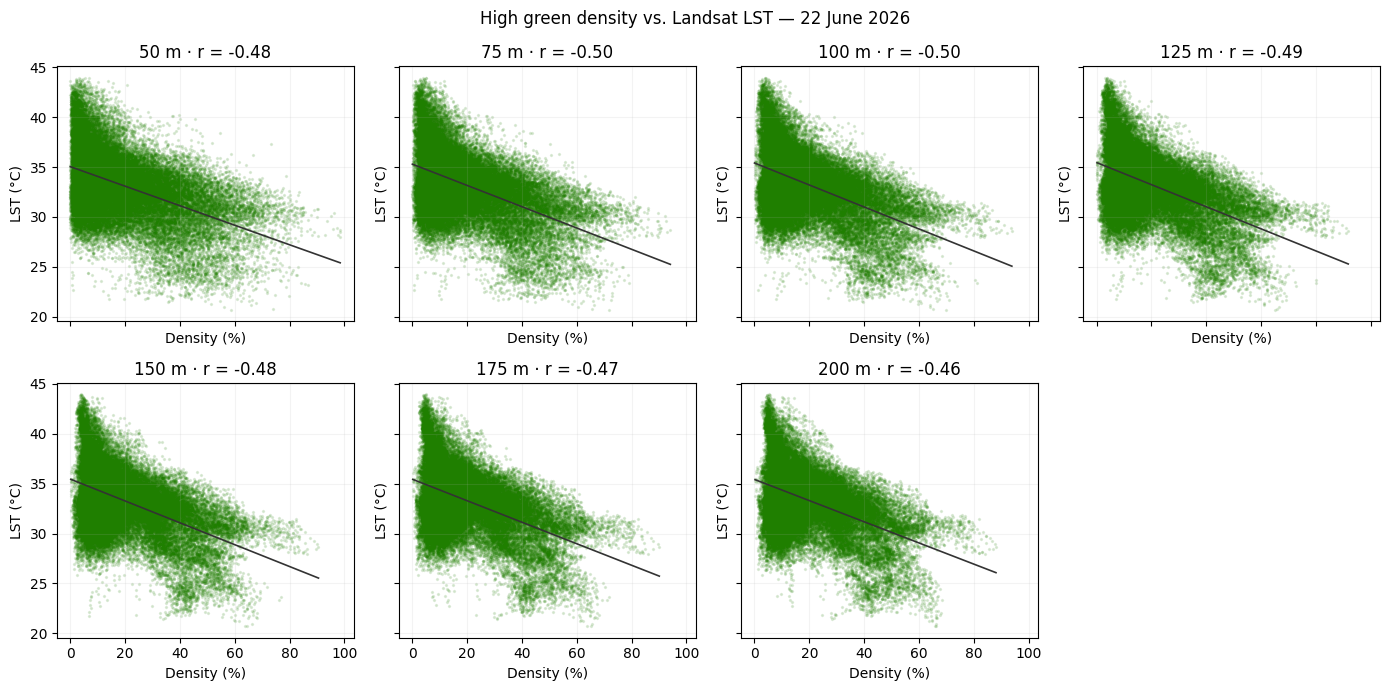

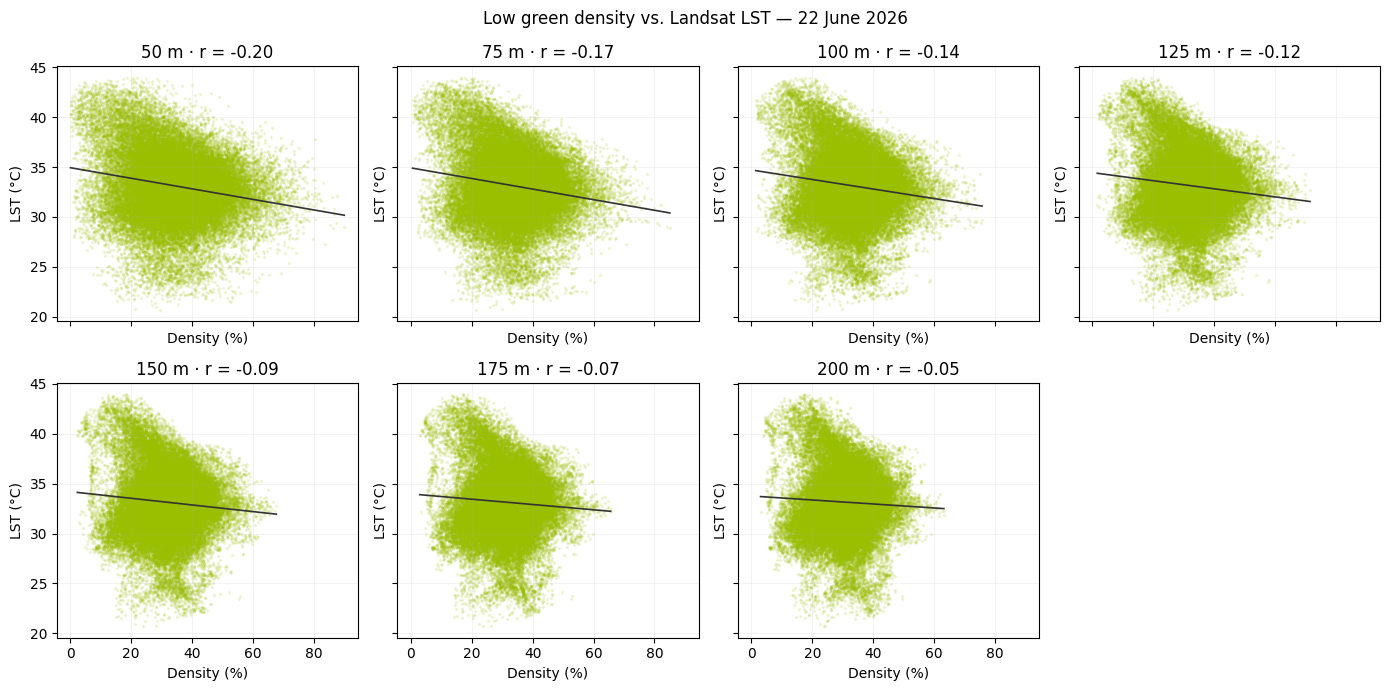

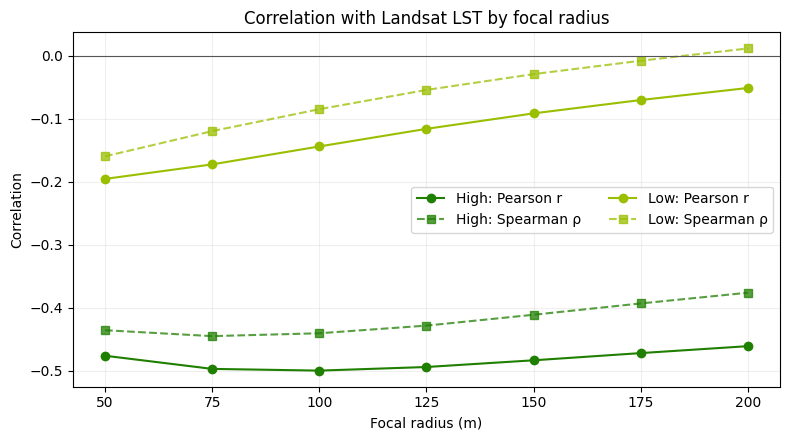

In [6]:
colors = ('#1f7f00', '#9abf00')
for green_index, (green_class, color) in enumerate(zip(('High green', 'Low green'), colors)):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
    for i, (radius, ax) in enumerate(zip(RADII, axes.flat)):
        x, y = point_values(i, green_index)
        m = metrics[2 * i + green_index]
        ax.scatter(x, y, s=2, alpha=0.12, color=color, rasterized=True)
        xx = np.array([x.min(), x.max()])
        ax.plot(xx, m['intercept'] + m['slope'] * xx, color='#333333', lw=1.2)
        ax.set_title(f'{radius} m · r = {m["pearson"]:.2f}')
        ax.set_xlabel('Density (%)')
        ax.set_ylabel('LST (°C)')
        ax.grid(alpha=0.15)
    axes.flat[-1].axis('off')
    fig.suptitle(f'{green_class} density vs. Landsat LST — 22 June 2026')
    fig.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for green_class, color in zip(('High', 'Low'), colors):
    selected = [m for m in metrics if m['green'] == green_class]
    ax.plot(RADII, [m['pearson'] for m in selected], 'o-', color=color, label=f'{green_class}: Pearson r')
    ax.plot(RADII, [m['spearman'] for m in selected], 's--', color=color, alpha=0.75, label=f'{green_class}: Spearman ρ')
ax.axhline(0, color='#555555', lw=0.8)
ax.set(xlabel='Focal radius (m)', ylabel='Correlation', title='Correlation with Landsat LST by focal radius')
ax.set_xticks(RADII)
ax.grid(alpha=0.2)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()